 Total workers: 1470
Leaving: 237
Staying: 1233
Attrition rate: 16.12%


C:\Users\niluc\AppData\Local\Temp\ipykernel_17264\546279676.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df,palette=['#4CAf50','#F44336'])


<Figure size 1400x800 with 0 Axes>

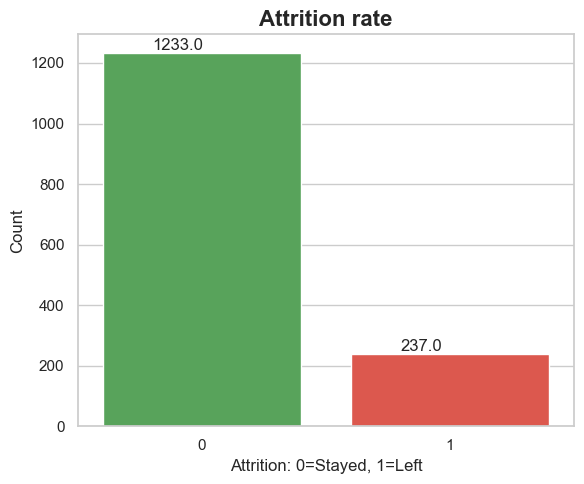

<Figure size 1400x800 with 0 Axes>

<Figure size 600x500 with 0 Axes>

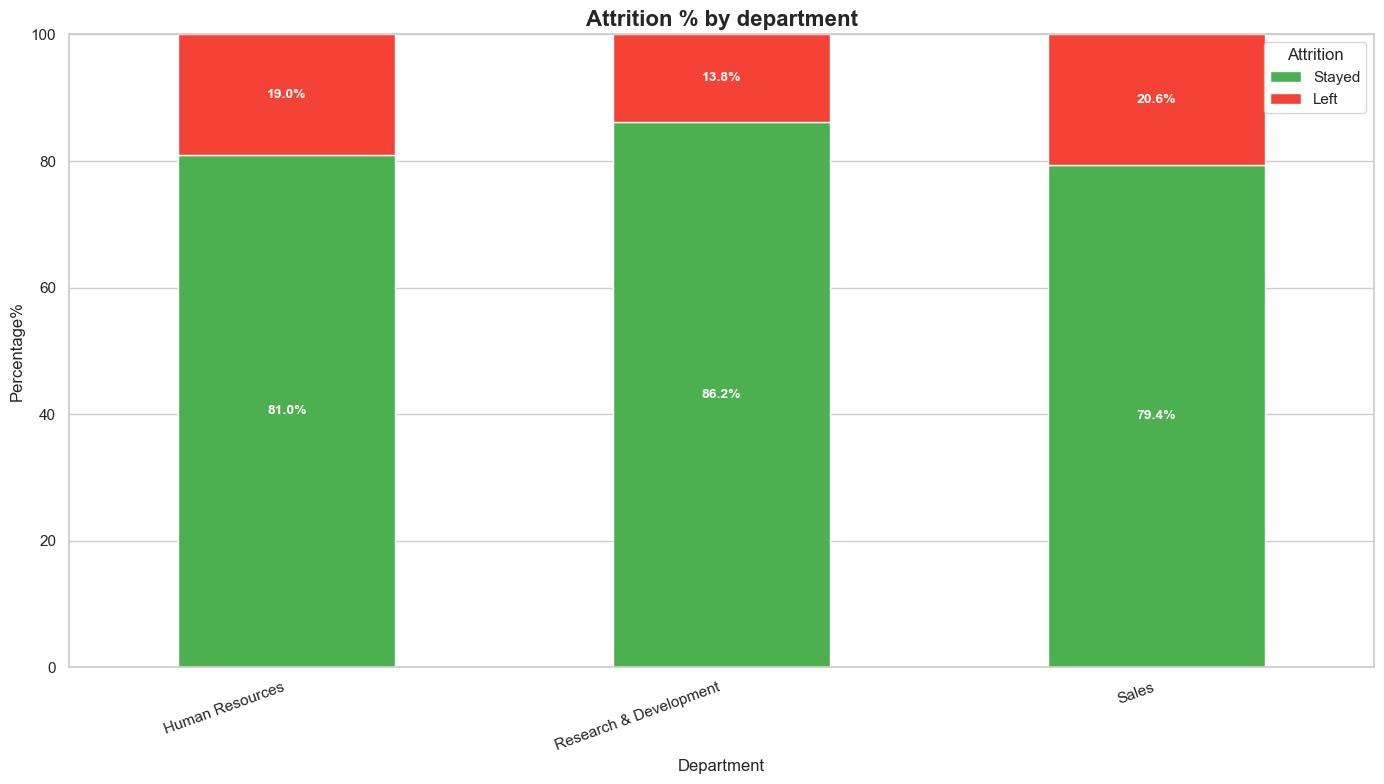

<Figure size 1400x800 with 0 Axes>

<Figure size 600x500 with 0 Axes>

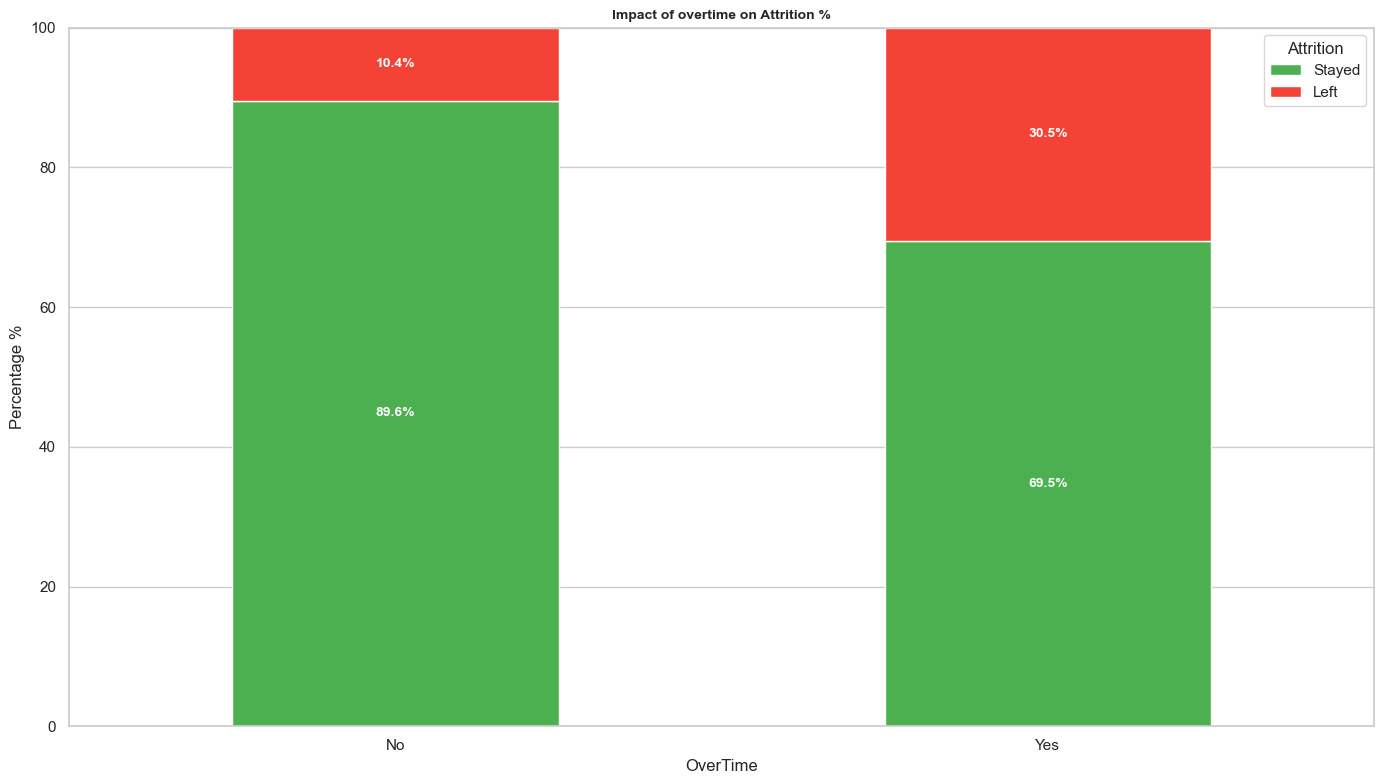

C:\Users\niluc\AppData\Local\Temp\ipykernel_17264\546279676.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', palette=['#4CAF50','#F44336'])


<Figure size 1400x800 with 0 Axes>

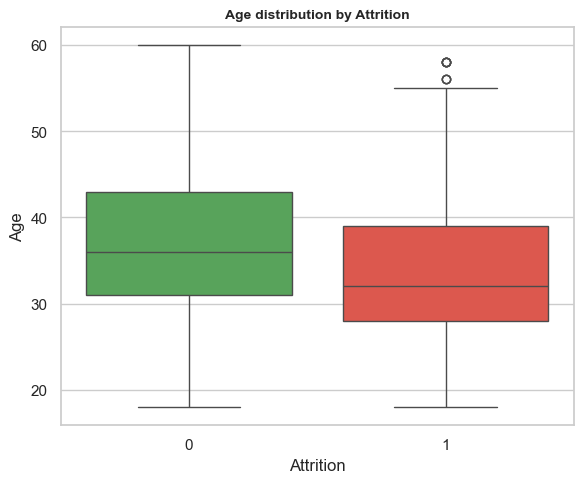

C:\Users\niluc\AppData\Local\Temp\ipykernel_17264\546279676.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x='Attrition',y='MonthlyIncome', palette=['#4CAF50','#F44336'])


<Figure size 1400x800 with 0 Axes>

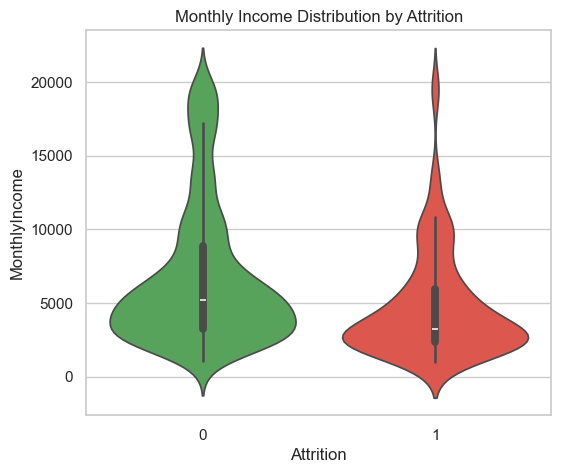

<Figure size 1400x800 with 0 Axes>

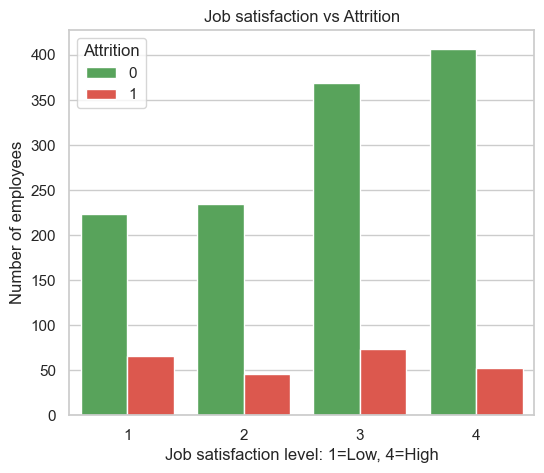


Engineering Features
High Risk Profile:40 employees flagged
Clean csv saved.


In [8]:

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df =pd.read_csv(r"C:\Users\niluc\Downloads\files\PROJECT\attrition\Data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape
df.isnull().sum()
df.duplicated().sum()

drop_cols = ['Over18','EmployeeCount','EmployeeNumber','StandardHours']
df = df.drop(drop_cols, axis=1)
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})
total = len(df)
leaving = df['Attrition'].sum()
staying = total - leaving
attrition_rate = (leaving / total)*100
print(f' Total workers: {total}')
print(f'Leaving: {leaving}')
print(f'Staying: {staying}')
print(f'Attrition rate: {attrition_rate:.2f}%')


#EDA
sns.set_theme(style='whitegrid',palette='Set2')
plt.rcParams['figure.figsize']=(14,8)

 #attrition rate
plt.clf()
plt.figure(figsize=(6,5))
sns.countplot(x='Attrition', data=df,palette=['#4CAf50','#F44336'])
plt.title('Attrition rate',fontsize=16,fontweight='bold')
plt.xlabel('Attrition: 0=Stayed, 1=Left')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}',(p.get_x()+0.2,p.get_height()+10))
plt.tight_layout()
plt.savefig('Attrition_rate.png',dpi=300,bbox_inches='tight')
plt.show()

#attrition by department
plt.clf()
plt.figure(figsize=(6,5))
dept_attr = pd.crosstab(df['Department'],df['Attrition'],normalize='index')*100
ax = dept_attr.plot(kind='bar',stacked=True,color=['#4CAF50','#F44336'])
plt.title('Attrition % by department',fontsize=16,fontweight='bold')
plt.ylabel('Percentage%')
plt.xlabel('Department')
plt.legend(['Stayed','Left'],title='Attrition')
plt.xticks(rotation=20,ha='right')
plt.ylim(0,100)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center',fontsize=10,color='white',fontweight='bold')
plt.savefig('Attrition_by_department.png',dpi=300,bbox_inches='tight')
plt.show()

#impact of overtime
plt.clf()
plt.figure(figsize=(6,5))
ot_attr = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')*100
ax = ot_attr.plot(kind='bar', stacked=True,color=['#4CAF50','#F44336'])
plt.title('Impact of overtime on Attrition %', fontsize=10,fontweight='bold')
plt.ylabel('Percentage %')
plt.xlabel('OverTime')
plt.legend(['Stayed','Left'], title='Attrition')
plt.xticks(rotation=0)
plt.ylim(0,100)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%',label_type='center',fontsize=10,color='white',fontweight='bold')
plt.savefig('overtime_impact.png',dpi=300,bbox_inches='tight')
plt.show()

#age distribution by attrition
plt.clf()
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Attrition', y='Age', palette=['#4CAF50','#F44336'])
plt.title('Age distribution by Attrition', fontsize=10,fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('Age_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

#attrition vs monthly income
plt.clf()
plt.figure(figsize=(6,5))
sns.violinplot(data=df,x='Attrition',y='MonthlyIncome', palette=['#4CAF50','#F44336'])
plt.title('Monthly Income Distribution by Attrition')
plt.savefig('Attrition_vs_monthly_income.png',dpi=300,bbox_inches='tight')
plt.show()

#job satisfaction
plt.clf()
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='JobSatisfaction',hue='Attrition',palette=['#4CAF50','#F44336'])
plt.title('Job satisfaction vs Attrition')
plt.xlabel('Job satisfaction level: 1=Low, 4=High')
plt.ylabel('Number of employees')
plt.legend(title='Attrition')
plt.savefig('Attrition_vs_jobsatisfaction.png',dpi=300,bbox_inches='tight')
plt.show()

df['OverTime']=df['OverTime'].map({'Yes': 1 ,'No': 0})
df['Gender'] =df['Gender'].map({'Male': 1 ,'Female': 0})
travel_map = {
    'Non-Travel'        :0, 
    'Travel_Rarely'     :1,
    'Travel_Frequently' :2,
}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_map)

nominal_cols = ['Department','EducationField','JobRole','MaritalStatus']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
print('\nEngineering Features')

#Feature engineering
df['LogMonthlyIncome'] =np.log1p(df['MonthlyIncome'])
df['YearsPerCompany'] = np.where(
    df['NumCompaniesWorked'] > 0,
    df['TotalWorkingYears'] / df['NumCompaniesWorked'],
    df['TotalWorkingYears']
)
df['PromotionLag'] = df['YearsSinceLastPromotion'] - df['YearsInCurrentRole']
df['IncomePerYear'] = (df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)).round(2)
single_col = 'MaritalStatus_Single'
if single_col:
    df['HighRiskProfile'] = (
        (df['Age'] < 32) & (df[single_col] == 1) & (df['BusinessTravel'] == 2)).astype(int)
    print(f'High Risk Profile:{df["HighRiskProfile"].sum()} employees flagged')
else:
    df['HighRiskProfile'] = 0

df.to_csv('Attrition_clean.csv', index=False)
print('Clean csv saved.')
